In [3]:
%matplotlib inline

In [4]:
import numpy as np
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

# ReadCSV file

In [6]:
df = pd.read_csv("Salary_dataset.csv")

In [7]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
type(df["YearsExperience"])

pandas.core.series.Series

In [9]:
df.count()

Unnamed: 0         30
YearsExperience    30
Salary             30
dtype: int64

In [10]:
x = df["YearsExperience"].to_numpy()
y = df["Salary"].to_numpy()

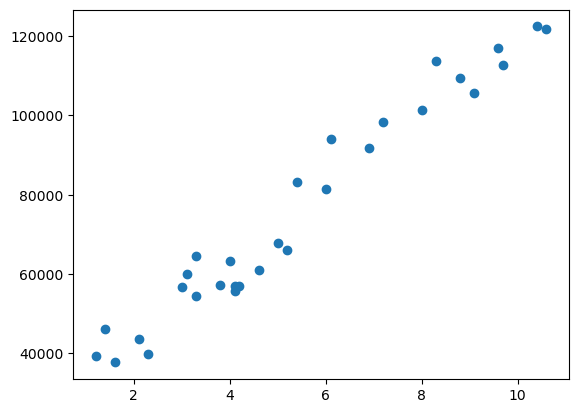

In [11]:
plt.scatter(x,y)
plt.show()

# Do some linear regression

As there is one variable formulating

y = x0*b0 + x1*b1

In [160]:
def showGraph(x, y, i1):
    x = x[:,1]
    plt.scatter(x,y)
    a = np.linspace(np.min(x), np.max(x), 10)
    plt.plot(a,i1[0] + i1[1]*a)
    plt.show()

def hypo(x, itr):
    itr = itr.reshape(2, 1)
    y = np.matmul(mt, itr)
    return y

def nextItr(x, y, itr, learn_rate):
    n = len(y)
    h = hypo(x, itr)
    learn_linear_cost = h-y.reshape(n, 1)
    b = np.matmul(np.transpose(x), learn_linear_cost)
    b = (learn_rate/n) * b
    return (itr.reshape(2, 1)-b).reshape(1, 2)

def runNItr(x, y, itr, learn_rate, n):
    it = itr
    for i in range(n):
        it = nextItr(x, y, it, learn_rate)
        # print(it)
        # showGraph(x, y, it[0])
    showGraph(x, y, it[0])
    return it
    

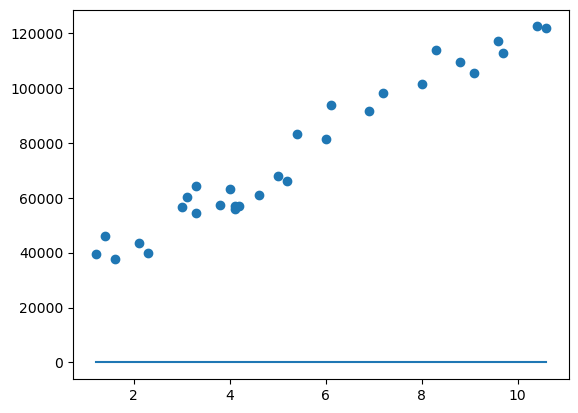

In [168]:
# x = np.array([[1, x[i]] for i in range(len(x))])
learn_rate = 0.01
i1 = np.array([0.5, 0])
showGraph(x, y, i1)


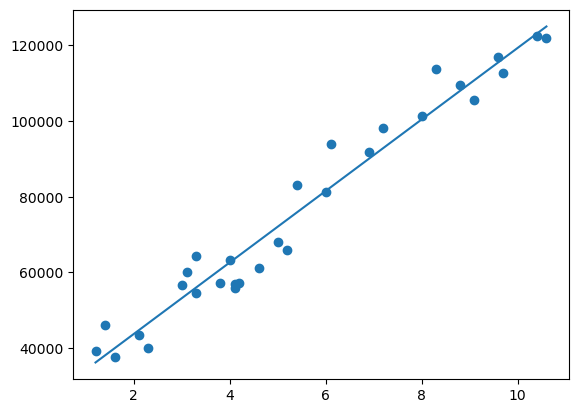

[[24848.20393979  9449.96232538]]


In [169]:
itr100 = runNItr(x, y, i1, learn_rate,10000)
print(itr100)

Iteration 0: Cost 6224.6094, theta0 = 109.3750, theta1 = 20.9631
Iteration 100: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 200: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 300: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 400: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 500: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 600: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 700: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 800: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263
Iteration 900: Cost 23.4375, theta0 = 218.7500, theta1 = 41.9263


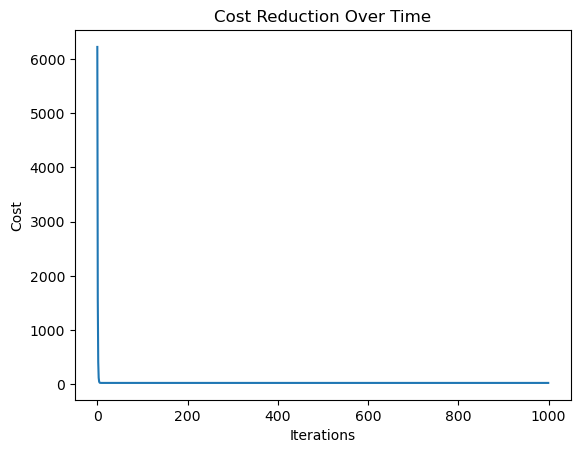

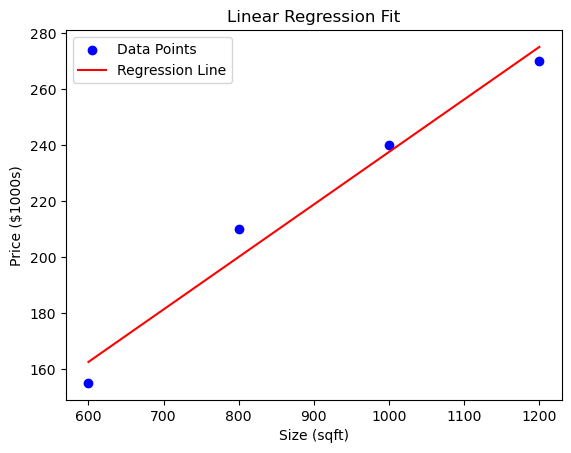

Predicted price for 1100 sqft: $256.25k


In [173]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Sample Data
X = np.array([600, 800, 1000, 1200], dtype=float)
Y = np.array([155, 210, 240, 270], dtype=float)

# Normalize the data (optional but helps with convergence)
X_mean = np.mean(X)
X_std = np.std(X)
X_norm = (X - X_mean) / X_std

# Step 2: Hypothesis - h(x) = theta0 + theta1 * x
theta0 = 0.0
theta1 = 0.0

# Step 3: Cost Function
def compute_cost(x, y, theta0, theta1):
    m = len(x)
    predictions = theta0 + theta1 * x
    return (1/(2*m)) * np.sum((predictions - y)**2)

# Step 4: Gradient Descent
def gradient_descent(x, y, theta0, theta1, alpha, iterations):
    m = len(x)
    cost_history = []

    for i in range(iterations):
        predictions = theta0 + theta1 * x
        error = predictions - y

        d_theta0 = (1/m) * np.sum(error)
        d_theta1 = (1/m) * np.sum(error * x)

        theta0 -= alpha * d_theta0
        theta1 -= alpha * d_theta1

        cost = compute_cost(x, y, theta0, theta1)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}, theta0 = {theta0:.4f}, theta1 = {theta1:.4f}")
    
    return theta0, theta1, cost_history

# Step 5: Training
alpha = 0.5      # Learning rate
iterations = 1000
theta0, theta1, cost_history = gradient_descent(X_norm, Y, theta0, theta1, alpha, iterations)

# Step 6: Plot cost over time
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

# Step 7: Plot fitted line
plt.scatter(X, Y, color='blue', label='Data Points')
X_line = np.linspace(min(X), max(X), 100)
X_line_norm = (X_line - X_mean) / X_std
Y_pred = theta0 + theta1 * X_line_norm
plt.plot(X_line, Y_pred, color='red', label='Regression Line')
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($1000s)")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

# Step 8: Prediction
def predict(x):
    x_norm = (x - X_mean) / X_std
    return theta0 + theta1 * x_norm

example_size = 1100
predicted_price = predict(example_size)
print(f"Predicted price for {example_size} sqft: ${predicted_price:.2f}k")
